C:\Users\asdxo\AppData\Local\Temp\ipykernel_18800\3670975085.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tail_analysis, x='performance_grade', y='long_tail_index',


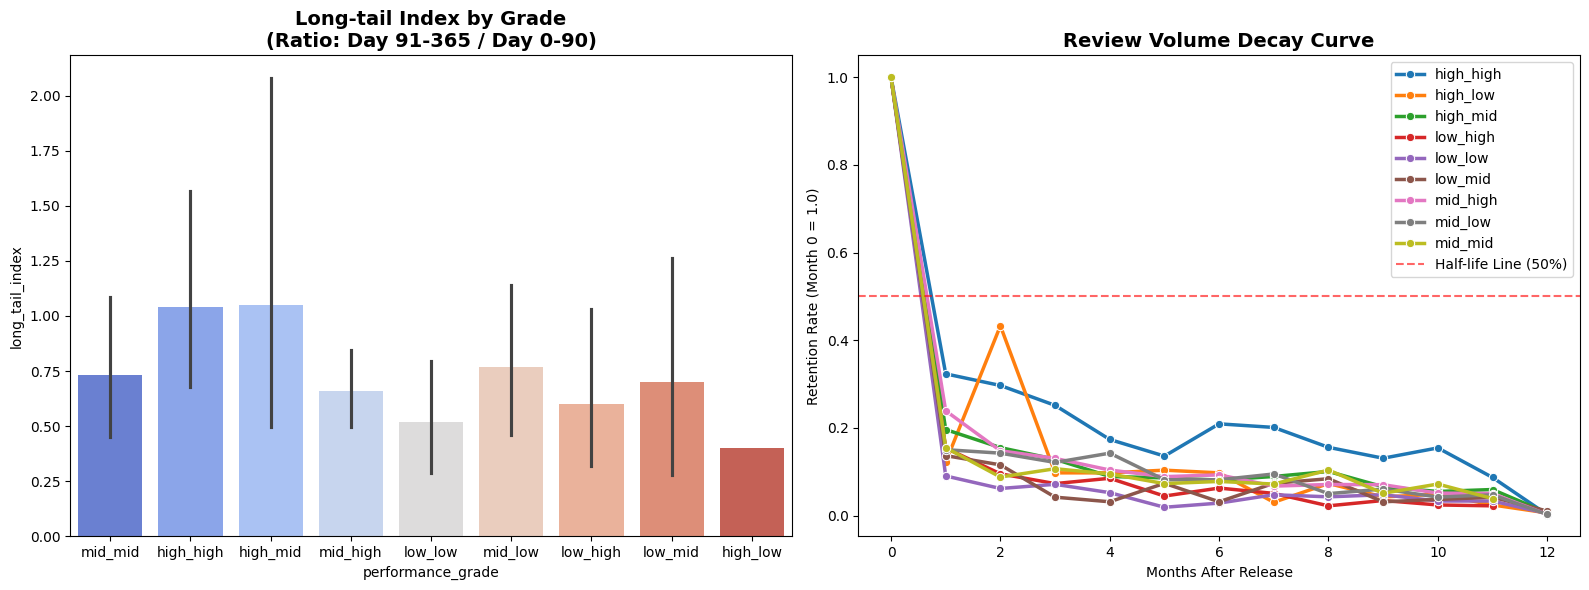

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리
games_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')

reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
games_df['release_date'] = pd.to_datetime(games_df['release_date'])

# 필요한 컬럼만 병합
merged = pd.merge(
    reviews_df[['appid', 'created_date']], 
    games_df[['appid', 'release_date', 'performance_grade']], 
    on='appid'
)
merged['days_since_release'] = (merged['created_date'] - merged['release_date']).dt.days

# 2. 롱테일 지수 (Long-tail Index) 계산
# 초기 90일 vs 이후 (91~365일) 비율
early_phase = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 90)]
long_phase = merged[(merged['days_since_release'] > 90) & (merged['days_since_release'] <= 365)]

early_counts = early_phase.groupby('appid').size().reset_index(name='early_reviews')
long_counts = long_phase.groupby('appid').size().reset_index(name='long_reviews')

tail_df = pd.merge(early_counts, long_counts, on='appid', how='left').fillna(0)
tail_df['long_tail_index'] = tail_df['long_reviews'] / tail_df['early_reviews']

# 등급 데이터와 병합
tail_analysis = pd.merge(tail_df, games_df[['appid', 'performance_grade']], on='appid')

# 3. 수명 주기 감쇄 곡선 데이터 생성 (30일 단위)
merged['month'] = merged['days_since_release'] // 30
decay_df = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 360)]
decay_curve = decay_df.groupby(['performance_grade', 'month']).size().reset_index(name='review_count')

# 상대적 유지율 계산 (Month 0 대비 비율)
initial_counts = decay_curve[decay_curve['month'] == 0][['performance_grade', 'review_count']].rename(columns={'review_count': 'initial_count'})
decay_curve = pd.merge(decay_curve, initial_counts, on='performance_grade')
decay_curve['retention'] = decay_curve['review_count'] / decay_curve['initial_count']

# 4. 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [좌] 롱테일 지수 비교 (지속성 확인)
sns.barplot(data=tail_analysis, x='performance_grade', y='long_tail_index', 
            palette='coolwarm', ax=axes[0], errorbar=('ci', 95))
axes[0].set_title('Long-tail Index by Grade\n(Ratio: Day 91-365 / Day 0-90)', fontsize=14, fontweight='bold')

# [우] 수명 주기 감쇄 곡선 (생존력 확인)
sns.lineplot(data=decay_curve, x='month', y='retention', hue='performance_grade', 
             marker='o', ax=axes[1], linewidth=2.5)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Half-life Line (50%)')
axes[1].set_title('Review Volume Decay Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Months After Release')
axes[1].set_ylabel('Retention Rate (Month 0 = 1.0)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
games_df['release_date'] = pd.to_datetime(games_df['release_date'])

# 데이터 병합
merged = pd.merge(
    reviews_df[['appid', 'created_date']], 
    games_df[['appid', 'release_date', 'performance_grade']], 
    on='appid'
)
merged['days_since_release'] = (merged['created_date'] - merged['release_date']).dt.days

# 2. 롱테일 지수 (Long-tail Index) 통계량 산출
early_phase = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 90)]
long_phase = merged[(merged['days_since_release'] > 90) & (merged['days_since_release'] <= 365)]

early_counts = early_phase.groupby('appid').size().reset_index(name='early_reviews')
long_counts = long_phase.groupby('appid').size().reset_index(name='long_reviews')

tail_df = pd.merge(early_counts, long_counts, on='appid', how='left').fillna(0)
tail_df['long_tail_index'] = tail_df['long_reviews'] / tail_df['early_reviews']
tail_analysis = pd.merge(tail_df, games_df[['appid', 'performance_grade']], on='appid')

# [출력 1] 등급별 롱테일 지수 상세 통계
tail_stats = tail_analysis.groupby('performance_grade')['long_tail_index'].agg(['count', 'mean', 'std', 'median']).sort_values(by='mean', ascending=False)

# 3. 월별 감쇄율 (Decay Rate) 상세 수치 산출
merged['month'] = merged['days_since_release'] // 30
decay_df = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 360)]
decay_curve = decay_df.groupby(['performance_grade', 'month']).size().reset_index(name='review_count')

# 초기 월(Month 0) 대비 비중 계산
initial_counts = decay_curve[decay_curve['month'] == 0][['performance_grade', 'review_count']].rename(columns={'review_count': 'initial_count'})
decay_curve = pd.merge(decay_curve, initial_counts, on='performance_grade')
decay_curve['retention_rate'] = decay_curve['review_count'] / decay_curve['initial_count']

# [출력 2] 주요 시점(Month 1, Month 11)의 유지율 비교
key_months = [0, 1, 6, 11]
pivot_decay = decay_curve[decay_curve['month'].isin(key_months)].pivot(
    index='performance_grade', 
    columns='month', 
    values='retention_rate'
).round(3)

print("="*80)
print("📊 1. 등급별 롱테일 지수 (Long-tail Index) 통계")
print("="*80)
print(tail_stats)
print("\n" + "="*80)
print("📉 2. 주요 시점별 리뷰 유지율 (Retention Rate) 비교 (Month 0 = 1.0)")
print("="*80)
print(pivot_decay)
print("="*80)

📊 1. 등급별 롱테일 지수 (Long-tail Index) 통계
                   count      mean       std    median
performance_grade                                     
high_mid               5  1.049261  1.140402  0.577778
high_high             30  1.041972  1.207644  0.688148
mid_low               10  0.768502  0.595778  0.629870
mid_mid               13  0.733312  0.648246  0.637037
low_mid                9  0.699367  0.776569  0.384615
mid_high              34  0.658246  0.518599  0.499112
low_high              54  0.600068  1.308174  0.250000
low_low               20  0.518351  0.612022  0.358974
high_low               1  0.400000       NaN  0.400000

📉 2. 주요 시점별 리뷰 유지율 (Retention Rate) 비교 (Month 0 = 1.0)
month              0.0    1.0    6.0    11.0
performance_grade                           
high_high           1.0  0.323  0.209  0.087
high_low            1.0  0.122  0.098  0.024
high_mid            1.0  0.196  0.081  0.060
low_high            1.0  0.154  0.063  0.022
low_low             1.0  0.090  

C:\Users\asdxo\AppData\Local\Temp\ipykernel_18800\835321194.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tail_analysis, x='performance_grade', y='long_tail_index',


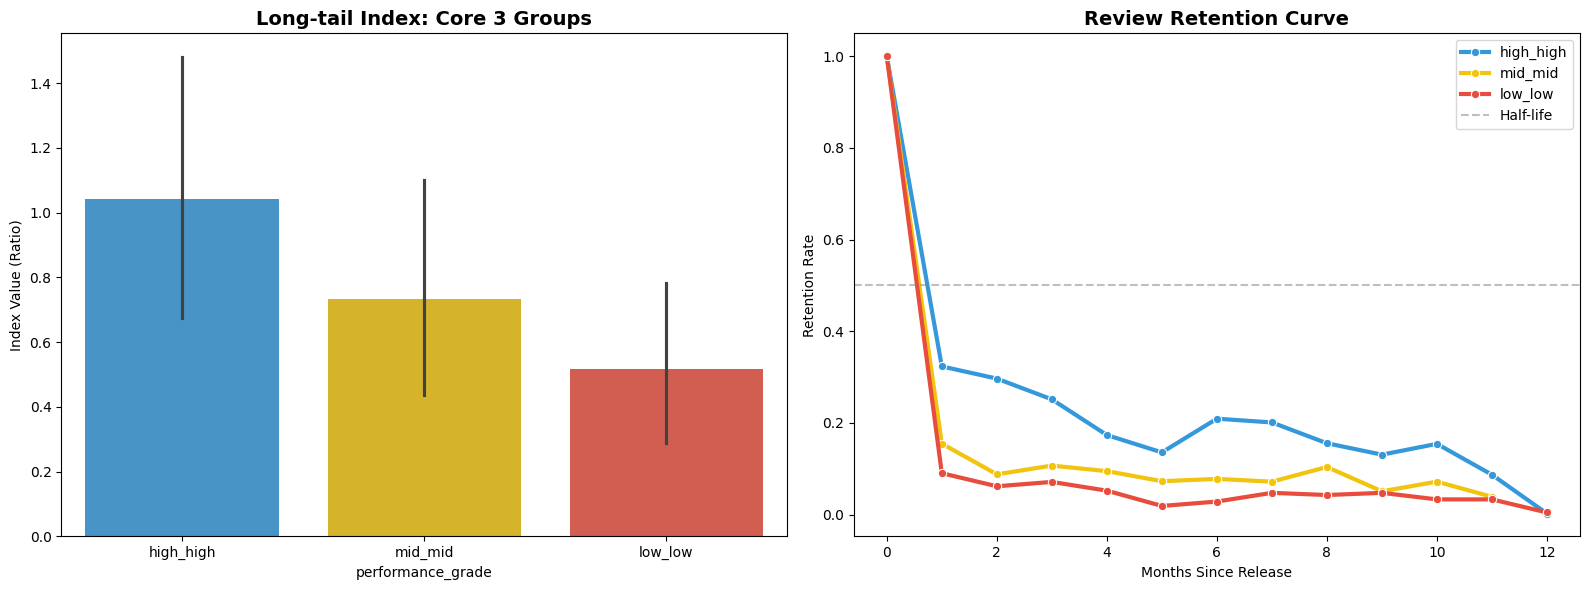

📌 3대 핵심 등급별 분석 요약 및 표본 오차
                   count   mean  median     moe
performance_grade                              
high_high             30  1.042   0.688  ±17.9%
low_low               20  0.518   0.359  ±21.9%
mid_mid               13  0.733   0.637  ±27.2%


In [8]:
reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
games_df['release_date'] = pd.to_datetime(games_df['release_date'])

# 데이터 병합 및 출시 후 경과일 계산
merged = pd.merge(
    reviews_df[['appid', 'created_date']], 
    games_df[['appid', 'release_date', 'performance_grade']], 
    on='appid'
)
merged['days_since_release'] = (merged['created_date'] - merged['release_date']).dt.days

# 분석 대상: 핵심 3대 그룹만 선정
target_grades = ['high_high', 'mid_mid', 'low_low']

# 2. 롱테일 지수(Long-tail Index) 계산
# 초기 90일 vs 이후(91~365일)
early_phase = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 90)]
long_phase = merged[(merged['days_since_release'] > 90) & (merged['days_since_release'] <= 365)]

early_counts = early_phase.groupby('appid').size().reset_index(name='early_reviews')
long_counts = long_phase.groupby('appid').size().reset_index(name='long_reviews')

tail_df = pd.merge(early_counts, long_counts, on='appid', how='left').fillna(0)
tail_df['long_tail_index'] = tail_df['long_reviews'] / tail_df['early_reviews']

# 등급 정보 결합 및 필터링
tail_analysis = pd.merge(tail_df, games_df[['appid', 'performance_grade']], on='appid')
tail_analysis = tail_analysis[tail_analysis['performance_grade'].isin(target_grades)]

# 3. 월별 리뷰 유지율(Retention Rate) 계산
merged['month'] = merged['days_since_release'] // 30
decay_df = merged[(merged['days_since_release'] >= 0) & (merged['days_since_release'] <= 360)]
decay_df = decay_df[decay_df['performance_grade'].isin(target_grades)]

decay_curve = decay_df.groupby(['performance_grade', 'month']).size().reset_index(name='review_count')

# Month 0 대비 비중 계산
initial_counts = decay_curve[decay_curve['month'] == 0][['performance_grade', 'review_count']].rename(columns={'review_count': 'initial_count'})
decay_curve = pd.merge(decay_curve, initial_counts, on='performance_grade')
decay_curve['retention_rate'] = decay_curve['review_count'] / decay_curve['initial_count']

# 4. 표본 오차(Margin of Error) 계산 함수 (95% 신뢰수준)
def calculate_moe(n, N=9692):
    if n == 0: return 0
    z = 1.96  # 95% 신뢰수준
    p = 0.5   # 최대 오차 가정
    fpc = np.sqrt((N - n) / (N - 1))  # 유한모집단 수정계수
    return z * np.sqrt((p * (1 - p)) / n) * fpc

# 통계 요약표 생성
tail_stats = tail_analysis.groupby('performance_grade')['long_tail_index'].agg(['count', 'mean', 'median']).round(3)
tail_stats['moe'] = [f"±{calculate_moe(n)*100:.1f}%" for n in tail_stats['count']]

# 5. 시각화 (두 개의 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {'high_high': '#3498db', 'mid_mid': '#f1c40f', 'low_low': '#e74c3c'}

# [좌] 롱테일 지수 비교 (신뢰구간 Error Bar 포함)
sns.barplot(data=tail_analysis, x='performance_grade', y='long_tail_index', 
            order=target_grades, palette=palette, ax=axes[0], errorbar=('ci', 95))
axes[0].set_title('Long-tail Index: Core 3 Groups', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index Value (Ratio)')

# [우] 수명 주기 감쇄 곡선
sns.lineplot(data=decay_curve, x='month', y='retention_rate', hue='performance_grade', 
             hue_order=target_grades, palette=palette, marker='o', ax=axes[1], linewidth=3)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Half-life')
axes[1].set_title('Review Retention Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Months Since Release')
axes[1].set_ylabel('Retention Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# 최종 리포트 출력
print("="*60)
print("📌 3대 핵심 등급별 분석 요약 및 표본 오차")
print("="*60)
print(tail_stats)
print("="*60)